In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
data= pd.read_csv("data/Transformed Data Set - Logistic regression.csv");

In [5]:
data

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,F
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,F
2,Warm,Rock,Wine,Coca Cola/Pepsi,F
3,Warm,Folk/Traditional,Whiskey,Fanta,F
4,Cool,Rock,Vodka,Coca Cola/Pepsi,F
...,...,...,...,...,...
61,Cool,Rock,Vodka,Coca Cola/Pepsi,M
62,Cool,Hip hop,Beer,Coca Cola/Pepsi,M
63,Neutral,Hip hop,Doesn't drink,Fanta,M
64,Cool,Rock,Wine,Coca Cola/Pepsi,M


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Favorite Color        66 non-null     object
 1   Favorite Music Genre  66 non-null     object
 2   Favorite Beverage     66 non-null     object
 3   Favorite Soft Drink   66 non-null     object
 4   Gender                66 non-null     object
dtypes: object(5)
memory usage: 2.7+ KB


In [8]:
data.describe(include='O').T

,count,unique,top,freq
Favorite Color,66,3,Cool,37
Favorite Music Genre,66,7,Rock,19
Favorite Beverage,66,6,Doesn't drink,14
Favorite Soft Drink,66,4,Coca Cola/Pepsi,32
Gender,66,2,F,33


In [9]:
data['Favorite Color'].value_counts()

Favorite Color
Cool       37
Warm       22
Neutral     7
Name: count, dtype: int64

In [10]:
data['Favorite Beverage'].value_counts()

Favorite Beverage
Doesn't drink    14
Beer             13
Other            11
Wine             10
Vodka             9
Whiskey           9
Name: count, dtype: int64

In [11]:
data.head()

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,F
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,F
2,Warm,Rock,Wine,Coca Cola/Pepsi,F
3,Warm,Folk/Traditional,Whiskey,Fanta,F
4,Cool,Rock,Vodka,Coca Cola/Pepsi,F


In [12]:
data.replace({'Gender':{'F':0,'M':1}},inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_5724\3460422156.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Gender':{'F':0,'M':1}},inplace=True)


In [13]:
data

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,0
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,0
2,Warm,Rock,Wine,Coca Cola/Pepsi,0
3,Warm,Folk/Traditional,Whiskey,Fanta,0
4,Cool,Rock,Vodka,Coca Cola/Pepsi,0
...,...,...,...,...,...
61,Cool,Rock,Vodka,Coca Cola/Pepsi,1
62,Cool,Hip hop,Beer,Coca Cola/Pepsi,1
63,Neutral,Hip hop,Doesn't drink,Fanta,1
64,Cool,Rock,Wine,Coca Cola/Pepsi,1


In [14]:
data['Favorite Color'].unique()

array(['Cool', 'Neutral', 'Warm'], dtype=object)

In [15]:
data.replace({'Favorite Color':{'Cool':0, 'Neutral':1, 'Warm':2}},inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_5724\4242037435.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Favorite Color':{'Cool':0, 'Neutral':1, 'Warm':2}},inplace=True)


In [16]:
data

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,0,Rock,Vodka,7UP/Sprite,0
1,1,Hip hop,Vodka,Coca Cola/Pepsi,0
2,2,Rock,Wine,Coca Cola/Pepsi,0
3,2,Folk/Traditional,Whiskey,Fanta,0
4,0,Rock,Vodka,Coca Cola/Pepsi,0
...,...,...,...,...,...
61,0,Rock,Vodka,Coca Cola/Pepsi,1
62,0,Hip hop,Beer,Coca Cola/Pepsi,1
63,1,Hip hop,Doesn't drink,Fanta,1
64,0,Rock,Wine,Coca Cola/Pepsi,1


In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
 le = LabelEncoder()

In [20]:
data.columns

Index(['Favorite Color', 'Favorite Music Genre', 'Favorite Beverage',
       'Favorite Soft Drink', 'Gender'],
      dtype='object')

In [24]:
for i in ['Favorite Music Genre', 'Favorite Beverage','Favorite Soft Drink']:
    data[i]=le.fit_transform(data[i])

In [25]:
data

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,0,6,3,0,0
1,1,2,3,1,0
2,2,6,5,1,0
3,2,1,4,2,0
4,0,6,3,1,0
...,...,...,...,...,...
61,0,6,3,1,1
62,0,2,0,1,1
63,1,2,1,2,1
64,0,6,5,1,1


In [26]:
data.dtypes

Favorite Color          int64
Favorite Music Genre    int64
Favorite Beverage       int64
Favorite Soft Drink     int64
Gender                  int64
dtype: object

In [31]:
x=data.drop('Gender',axis=1)
y=data['Gender']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
sdc=StandardScaler()

In [36]:
for i in [x_train,x_test]:
    i=sdc.fit_transform(i)

In [37]:
x_train

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink
11,2,4,2,0
25,2,5,4,1
21,2,3,4,2
29,0,0,1,2
42,2,5,1,1
45,0,2,0,1
46,0,2,5,1
40,0,6,3,1
56,2,1,2,2
37,0,4,2,2


In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
LR = LogisticRegression()

In [40]:
LR.fit(x_train,y_train)

LogisticRegression()

In [42]:
y_pred = LR.predict(x_test)

In [43]:
y_pred

array([0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1])

In [44]:
y_test

59    1
55    1
1     0
15    0
43    1
14    0
60    1
31    0
62    1
8     0
33    1
44    1
0     0
52    1
Name: Gender, dtype: int64

In [45]:
from sklearn.metrics import accuracy_score

In [46]:
accuracy_score(y_test,y_pred)

0.5714285714285714

In [47]:
from sklearn.metrics import confusion_matrix

In [48]:
cm = confusion_matrix(y_test,y_pred)

In [49]:
cm

array([[4, 2],
       [4, 4]])

In [50]:
len(y_test)

14

<Axes: >

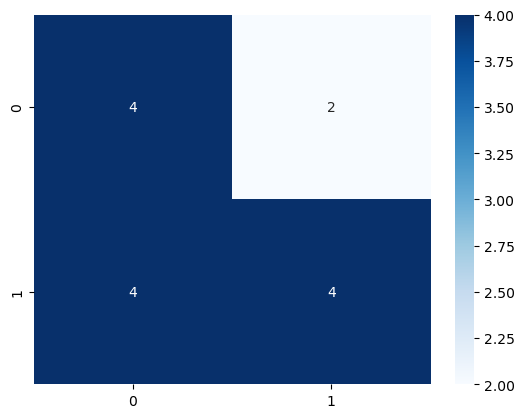

In [52]:
sns.heatmap(cm,annot=True,cmap='Blues')